In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [56]:
# Define commonly used project folders
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
RESULTS = PROJECT_ROOT / "results"
DATA_MODELING = PROJECT_ROOT / "data" / "modeling"

In [4]:
print("Project root:", PROJECT_ROOT)
print("Raw data path:", DATA_RAW)

Project root: D:\multi-horizon-asset-price-forecasting
Raw data path: D:\multi-horizon-asset-price-forecasting\data\raw


In [5]:
list(DATA_RAW.iterdir())

[WindowsPath('D:/multi-horizon-asset-price-forecasting/data/raw/.gitkeep'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/raw/BTCUSD.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/raw/ETHUSD.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/raw/GOOGL.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/raw/QQQ.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/raw/TSLA.csv')]

In [6]:
tsla=pd.read_csv(DATA_RAW/'TSLA.CSV')

In [7]:
tsla.head()

,Date,Open,High,Low,Close,Volume
0,2010-06-28,1.13333,1.13333,1.13333,1.13333,0
1,2010-06-29,1.26667,1.66667,1.16933,1.59267,281749140
2,2010-06-30,1.71933,2.02800,1.55333,1.58867,257915910
3,2010-07-01,1.66667,1.72800,1.35133,1.46400,123447945
4,2010-07-02,1.53333,1.54000,1.24733,1.28000,77127105


In [8]:
tsla.info()

<class 'pandas.DataFrame'>
RangeIndex: 4064 entries, 0 to 4063
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4064 non-null   str    
 1   Open    4064 non-null   float64
 2   High    4064 non-null   float64
 3   Low     4064 non-null   float64
 4   Close   4064 non-null   float64
 5   Volume  4064 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 190.6 KB


In [9]:
tsla.tail()

,Date,Open,High,Low,Close,Volume
4059,2026-08-19,338.89,351.62,335.7000,351.12,36735428
4060,2026-08-20,346.20,347.50,338.9600,345.13,30766360
4061,2026-08-21,349.88,366.50,346.9000,362.86,59223958
4062,2026-08-24,361.41,363.24,348.2600,348.95,39190484
4063,2026-08-25,349.58,357.00,349.2003,350.25,29816685


In [10]:
tsla['Date']=pd.to_datetime(tsla['Date'])

In [11]:
tsla.info()

<class 'pandas.DataFrame'>
RangeIndex: 4064 entries, 0 to 4063
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4064 non-null   datetime64[us]
 1   Open    4064 non-null   float64       
 2   High    4064 non-null   float64       
 3   Low     4064 non-null   float64       
 4   Close   4064 non-null   float64       
 5   Volume  4064 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 190.6 KB


In [12]:
tsla.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [13]:
tsla.duplicated().sum()

np.int64(0)

In [14]:
tsla['Date'].duplicated().sum()

np.int64(0)

In [15]:
invalid_ohlc = tsla[
    (tsla["High"] < tsla["Low"]) |
    (tsla["High"] < tsla["Open"]) |
    (tsla["High"] < tsla["Close"]) |
    (tsla["Low"] > tsla["Open"]) |
    (tsla["Low"] > tsla["Close"])
]

invalid_ohlc

,Date,Open,High,Low,Close,Volume


In [16]:
(tsla[["Open", "High", "Low", "Close"]] <= 0).sum()


Open     0
High     0
Low      0
Close    0
dtype: int64

In [17]:
(tsla["Volume"] < 0).sum()

np.int64(0)

In [18]:
(tsla["Volume"] == 0).sum()

np.int64(1)

In [30]:
tsla=tsla.set_index('Date')

In [32]:
tsla.to_csv(DATA_PROCESSED/'TSLA_processed.csv')

In [33]:
list(DATA_PROCESSED.iterdir())

[WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/.gitkeep'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/TSLA_processed.csv')]

In [19]:
def clean_stooq_data(df):
    """
    Clean and validate Stooq historical price data.

    Required columns:
    Date, Open, High, Low, Close

    Optional column:
    Volume
    """

    # 1. Make a copy to avoid modifying the original dataframe
    cleaned_df = df.copy()

    # 2. Convert Date column to datetime
    cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])

    # 3. Sort data from oldest to newest
    cleaned_df = cleaned_df.sort_values("Date")

    # 4. Remove duplicate rows
    cleaned_df = cleaned_df.drop_duplicates()

    # 5. Remove duplicate dates
    cleaned_df = cleaned_df.drop_duplicates(subset="Date")

    # 6. Check missing values
    print("Missing values:")
    print(cleaned_df.isnull().sum())

    # 7. Check OHLC consistency
    invalid_ohlc = cleaned_df[
        (cleaned_df["High"] < cleaned_df["Low"]) |
        (cleaned_df["High"] < cleaned_df["Open"]) |
        (cleaned_df["High"] < cleaned_df["Close"]) |
        (cleaned_df["Low"] > cleaned_df["Open"]) |
        (cleaned_df["Low"] > cleaned_df["Close"])
    ]

    print("\nInvalid OHLC rows:", len(invalid_ohlc))

    # 8. Check non-positive prices
    non_positive_prices = (
        cleaned_df[["Open", "High", "Low", "Close"]] <= 0
    ).sum()

    print("\nNon-positive prices:")
    print(non_positive_prices)

    # 9. Check Volume only if the column exists
    if "Volume" in cleaned_df.columns:
        print("\nNegative volume:", (cleaned_df["Volume"] < 0).sum())
        print("Zero volume:", (cleaned_df["Volume"] == 0).sum())
    else:
        print("\nVolume column not available.")

    # 10. Set Date as index
    cleaned_df = cleaned_df.set_index("Date")

    return cleaned_df

In [20]:
googl = pd.read_csv(DATA_RAW / "GOOGL.csv")
qqq = pd.read_csv(DATA_RAW / "QQQ.csv")
btcusd = pd.read_csv(DATA_RAW / "BTCUSD.csv")

In [21]:
googl_clean = clean_stooq_data(googl)
qqq_clean = clean_stooq_data(qqq)
btcusd_clean = clean_stooq_data(btcusd)

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Invalid OHLC rows: 0

Non-positive prices:
Open     0
High     0
Low      0
Close    0
dtype: int64

Negative volume: 0
Zero volume: 1
Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Invalid OHLC rows: 0

Non-positive prices:
Open     0
High     0
Low      0
Close    0
dtype: int64

Negative volume: 0
Zero volume: 0
Missing values:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Invalid OHLC rows: 0

Non-positive prices:
Open     0
High     0
Low      0
Close    0
dtype: int64

Volume column not available.


In [42]:
googl_clean.to_csv(DATA_PROCESSED/'GOOGL_processes.csv')

In [43]:
qqq_clean.to_csv(DATA_PROCESSED / "QQQ_processed.csv")
btcusd_clean.to_csv(DATA_PROCESSED / "BTCUSD_processed.csv")


In [48]:
list(DATA_PROCESSED.iterdir())

[WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/.gitkeep'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/BTCUSD_processed.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/GOOGL_processes.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/QQQ_processed.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/TSLA_processed.csv')]

In [22]:
eth=pd.read_csv(DATA_RAW/'ETHUSD.csv',sep=';')

In [23]:
eth.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,circulatingSupply,timestamp
0,2026-08-25T00:00:00.000Z,2026-08-25T23:59:59.999Z,2026-08-25T02:31:00.000Z,2026-08-25T21:09:00.000Z,2781,2481.777745,2531.084546,2416.602717,2443.159467,1.727086e+10,2.947628e+11,1.206813e+08,2026-08-25T23:59:59.999Z
1,2026-08-24T00:00:00.000Z,2026-08-24T23:59:59.999Z,2026-08-24T15:28:00.000Z,2026-08-24T02:03:00.000Z,2781,2463.640662,2531.744821,2425.387936,2481.831280,2.285223e+10,2.995047e+11,1.206815e+08,2026-08-24T23:59:59.999Z
2,2026-08-23T00:00:00.000Z,2026-08-23T23:59:59.999Z,2026-08-23T21:35:00.000Z,2026-08-23T05:18:00.000Z,2781,2424.217124,2483.930367,2357.139895,2463.815947,1.826925e+10,2.973159e+11,1.206815e+08,2026-08-23T23:59:59.999Z
3,2026-08-22T00:00:00.000Z,2026-08-22T23:59:59.999Z,2026-08-22T04:43:00.000Z,2026-08-22T10:24:00.000Z,2781,2515.392280,2528.896640,2389.902008,2424.251232,2.398529e+10,2.925583e+11,1.206816e+08,2026-08-22T23:59:59.999Z
4,2026-08-21T00:00:00.000Z,2026-08-21T23:59:59.999Z,2026-08-21T22:10:00.000Z,2026-08-21T00:05:00.000Z,2781,2326.382226,2545.881089,2324.709573,2515.281795,3.332857e+10,3.035618e+11,1.206817e+08,2026-08-21T23:59:59.999Z


In [24]:
eth.info()

<class 'pandas.DataFrame'>
RangeIndex: 4037 entries, 0 to 4036
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timeOpen           4037 non-null   str    
 1   timeClose          4037 non-null   str    
 2   timeHigh           4037 non-null   str    
 3   timeLow            4037 non-null   str    
 4   name               4037 non-null   int64  
 5   open               4037 non-null   float64
 6   high               4037 non-null   float64
 7   low                4037 non-null   float64
 8   close              4037 non-null   float64
 9   volume             4037 non-null   float64
 10  marketCap          4037 non-null   float64
 11  circulatingSupply  4037 non-null   float64
 12  timestamp          4037 non-null   str    
dtypes: float64(7), int64(1), str(5)
memory usage: 410.1 KB


In [25]:
eth["Date"] = pd.to_datetime(eth["timestamp"])

eth = eth[
    ["Date", "open", "high", "low", "close", "volume"]
].copy()

eth.columns = [
    "Date", "Open", "High", "Low", "Close", "Volume"
]

In [26]:
eth.head()

,Date,Open,High,Low,Close,Volume
0,2026-08-25 23:59:59.999000+00:00,2481.777745,2531.084546,2416.602717,2443.159467,1.727086e+10
1,2026-08-24 23:59:59.999000+00:00,2463.640662,2531.744821,2425.387936,2481.831280,2.285223e+10
2,2026-08-23 23:59:59.999000+00:00,2424.217124,2483.930367,2357.139895,2463.815947,1.826925e+10
3,2026-08-22 23:59:59.999000+00:00,2515.392280,2528.896640,2389.902008,2424.251232,2.398529e+10
4,2026-08-21 23:59:59.999000+00:00,2326.382226,2545.881089,2324.709573,2515.281795,3.332857e+10


In [27]:
eth.info()

<class 'pandas.DataFrame'>
RangeIndex: 4037 entries, 0 to 4036
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    4037 non-null   datetime64[us, UTC]
 1   Open    4037 non-null   float64            
 2   High    4037 non-null   float64            
 3   Low     4037 non-null   float64            
 4   Close   4037 non-null   float64            
 5   Volume  4037 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(5)
memory usage: 189.4 KB


In [28]:
eth["Date"] = pd.to_datetime(eth["Date"]).dt.date

In [29]:
eth=eth.sort_values('Date')

In [30]:
eth.head()

,Date,Open,High,Low,Close,Volume
4036,2015-08-07,2.831620,3.536610,2.521120,2.772120,164329.0
4035,2015-08-08,2.793760,2.798810,0.714725,0.753325,674188.0
4034,2015-08-09,0.706136,0.879810,0.629191,0.701897,532170.0
4033,2015-08-10,0.713989,0.729854,0.636546,0.708448,405283.0
4032,2015-08-11,0.708087,1.131410,0.663235,1.067860,1463100.0


In [31]:
eth.info()

<class 'pandas.DataFrame'>
RangeIndex: 4037 entries, 4036 to 0
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4037 non-null   object 
 1   Open    4037 non-null   float64
 2   High    4037 non-null   float64
 3   Low     4037 non-null   float64
 4   Close   4037 non-null   float64
 5   Volume  4037 non-null   float64
dtypes: float64(5), object(1)
memory usage: 189.4+ KB


In [32]:
eth=eth.set_index('Date')

In [33]:
eth.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-08-07,2.831620,3.536610,2.521120,2.772120,164329.0
2015-08-08,2.793760,2.798810,0.714725,0.753325,674188.0
2015-08-09,0.706136,0.879810,0.629191,0.701897,532170.0
2015-08-10,0.713989,0.729854,0.636546,0.708448,405283.0
2015-08-11,0.708087,1.131410,0.663235,1.067860,1463100.0


In [73]:
eth.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-08-21,2326.382226,2545.881089,2324.709573,2515.281795,3.332857e+10
2026-08-22,2515.392280,2528.896640,2389.902008,2424.251232,2.398529e+10
2026-08-23,2424.217124,2483.930367,2357.139895,2463.815947,1.826925e+10
2026-08-24,2463.640662,2531.744821,2425.387936,2481.831280,2.285223e+10
2026-08-25,2481.777745,2531.084546,2416.602717,2443.159467,1.727086e+10


In [75]:
eth.to_csv(DATA_PROCESSED/'ETHUSD_processes.csv')

In [76]:
list(DATA_PROCESSED.iterdir())

[WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/.gitkeep'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/BTCUSD_processed.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/ETHUSD_processes.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/GOOGL_processes.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/QQQ_processed.csv'),
 WindowsPath('D:/multi-horizon-asset-price-forecasting/data/processed/TSLA_processed.csv')]

In [36]:
# EDA

In [ ]:
# Historical Price Trend

In [3]:
tsla = pd.read_csv(DATA_PROCESSED / "TSLA_processed.csv")
googl = pd.read_csv(DATA_PROCESSED / "GOOGL_processed.csv")
btc = pd.read_csv(DATA_PROCESSED / "BTCUSD_processed.csv")
eth = pd.read_csv(DATA_PROCESSED / "ETHUSD_processed.csv")
qqq = pd.read_csv(DATA_PROCESSED / "QQQ_processed.csv")

In [4]:
for df in [tsla,googl,btc,eth]:
    df['Date']=pd.to_datetime(df['Date'])
    df=df.set_index('Date')

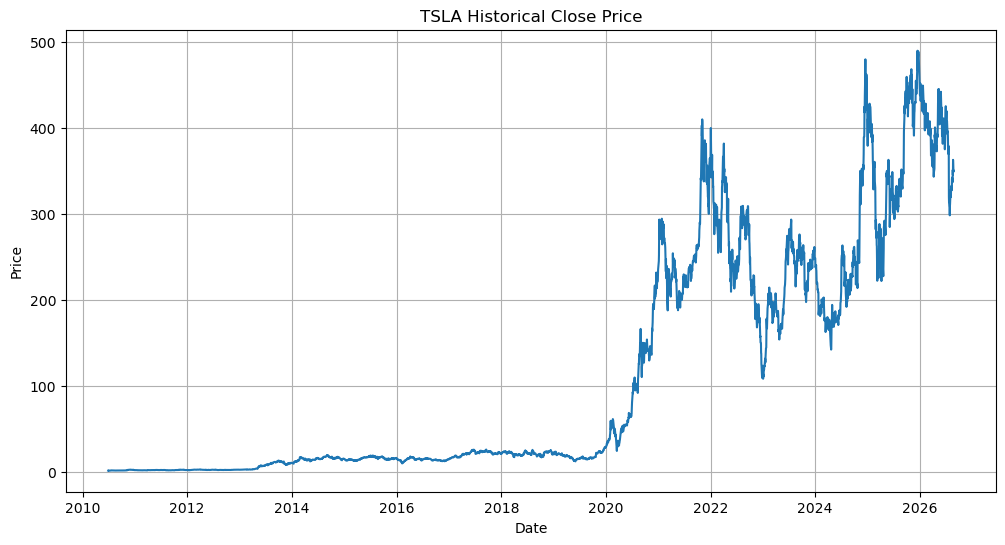

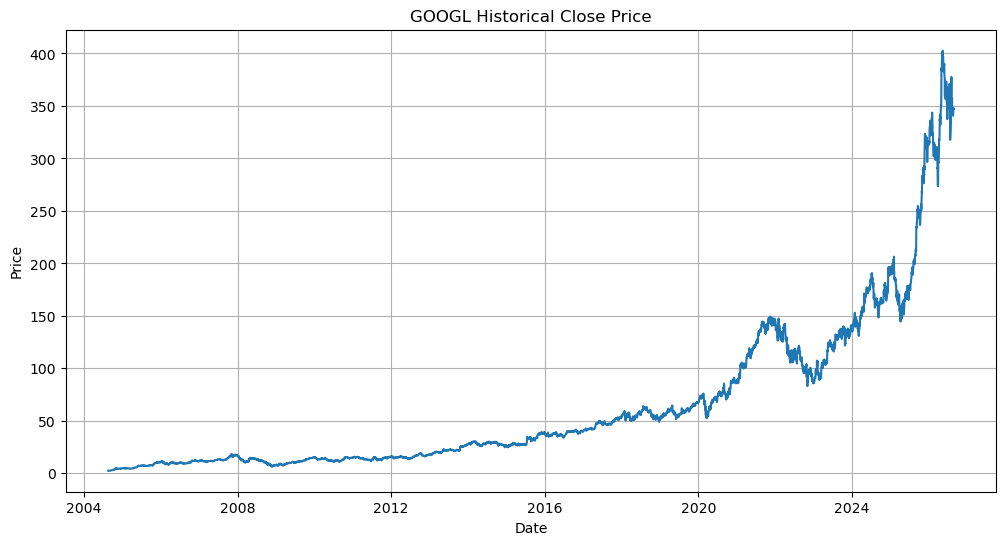

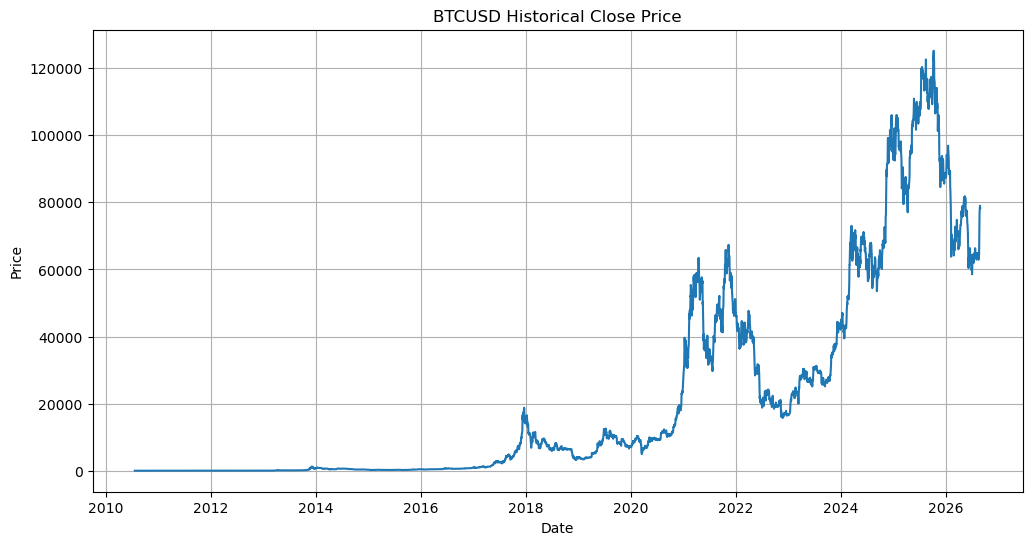

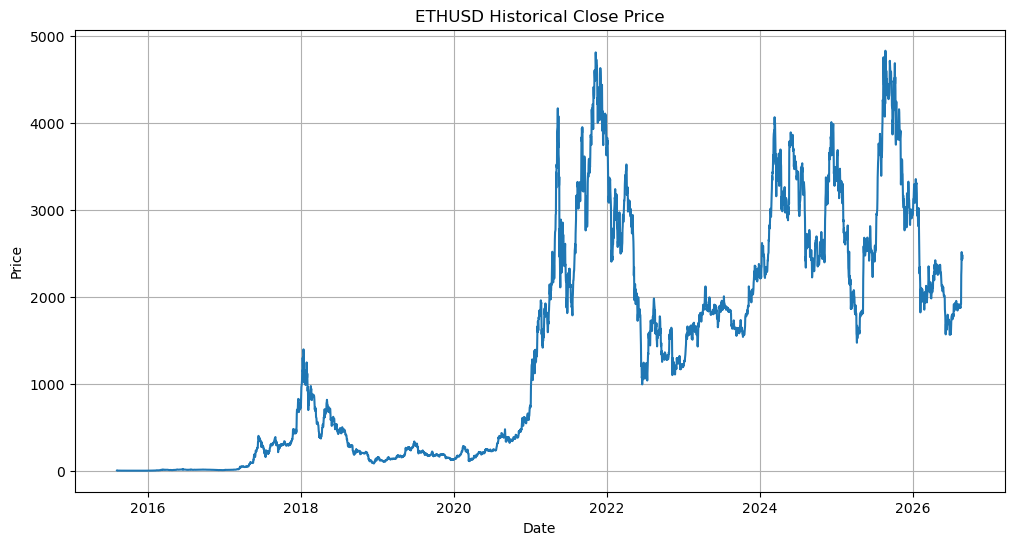

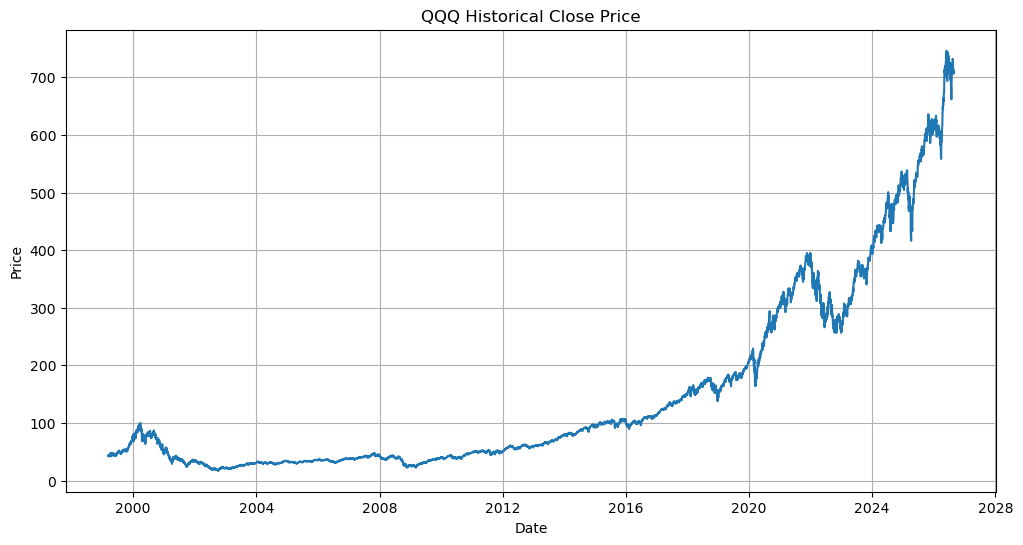

In [14]:
assets = {
    'TSLA': tsla,
    'GOOGL': googl,
    'BTCUSD': btc,
    'ETHUSD': eth,
    'QQQ':qqq
}

for name,df in assets.items():
    plt.figure(figsize=(12,6))

    plt.plot(df['Date'],df['Close'])

    plt.title(f'{name} Historical Close Price')

    plt.xlabel('Date')

    plt.ylabel('Price')

    plt.grid(True)

    plt.savefig(FIGURES/f'{name}_historical_close_price.png',
    dpi=300,
    bbox_inches='tight'
    )

    plt.show()
    

In [30]:
for name,df in assets.items():
    df['Daily Return']=df['Close'].pct_change()

In [ ]:
# Daily Return

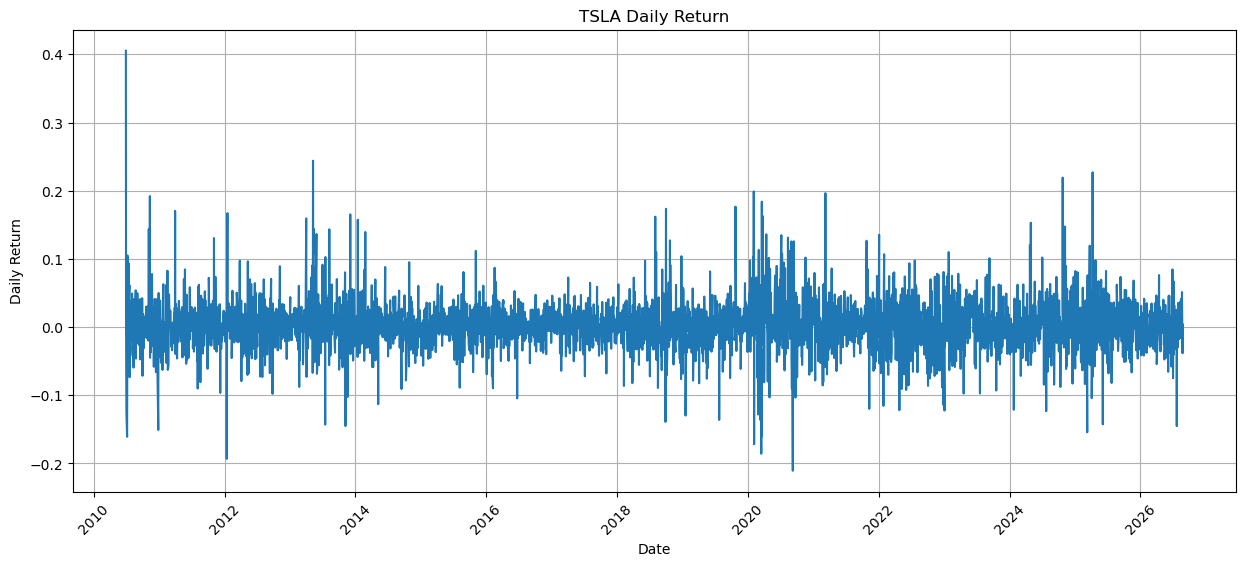

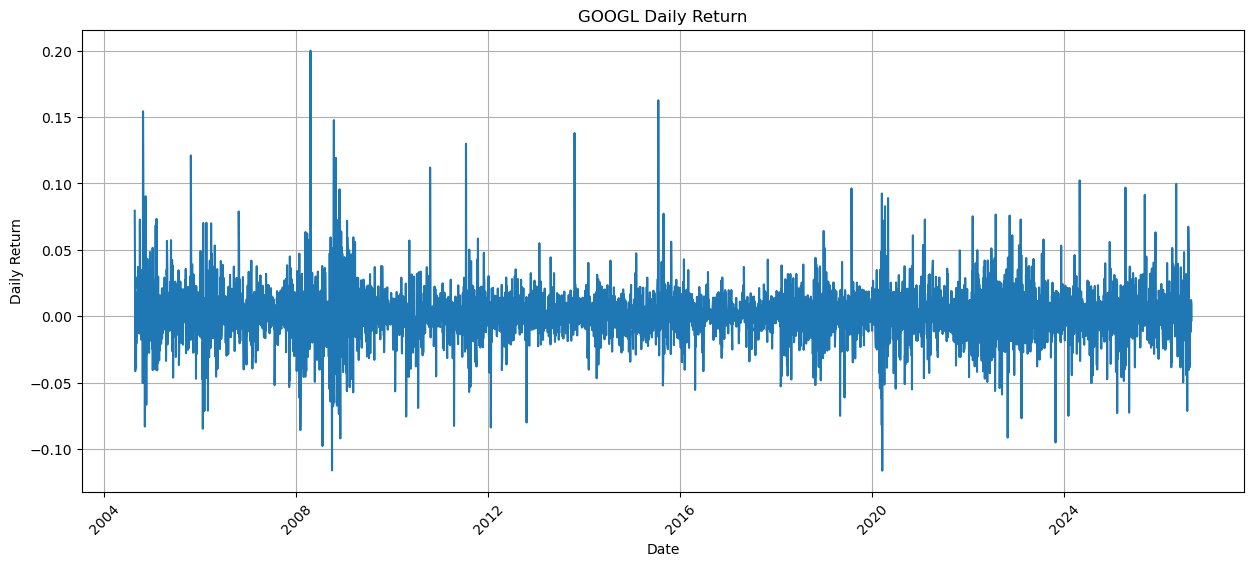

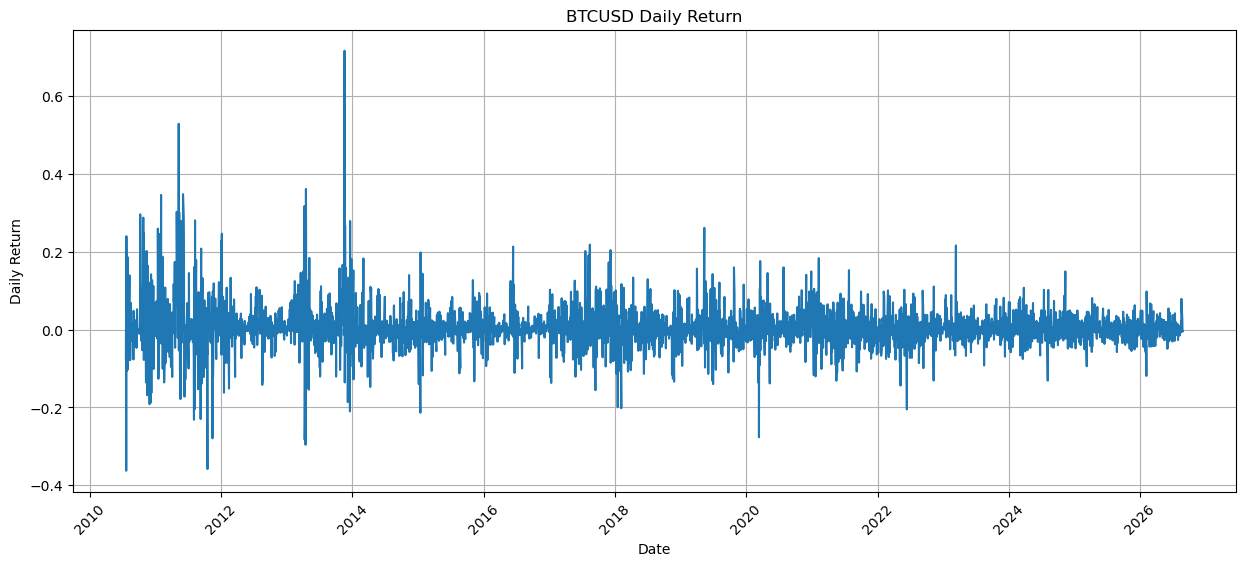

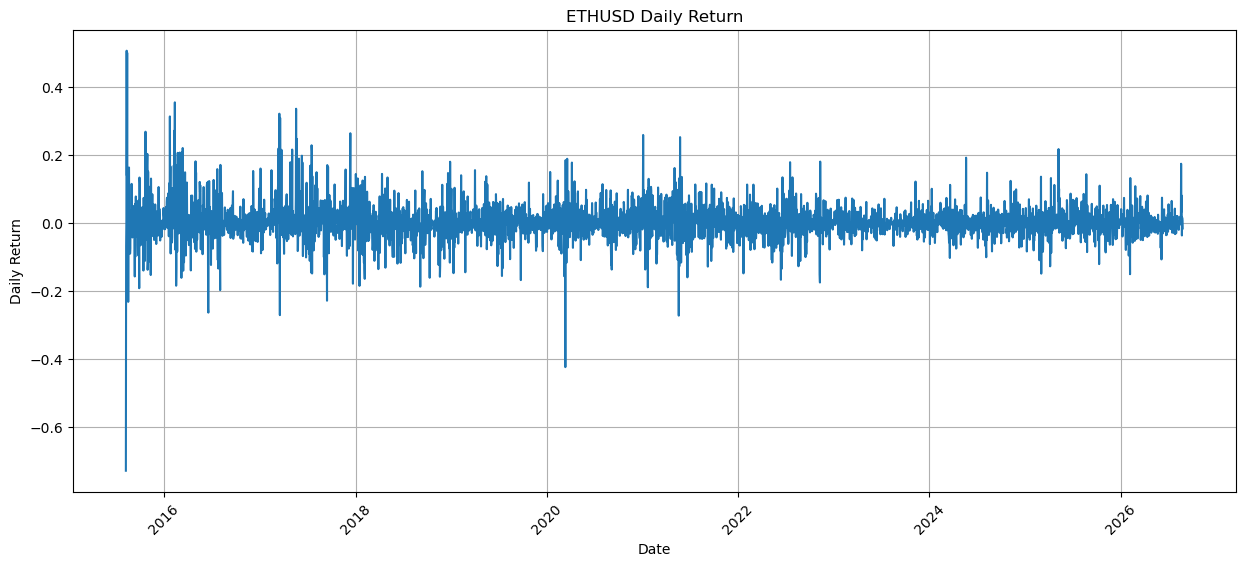

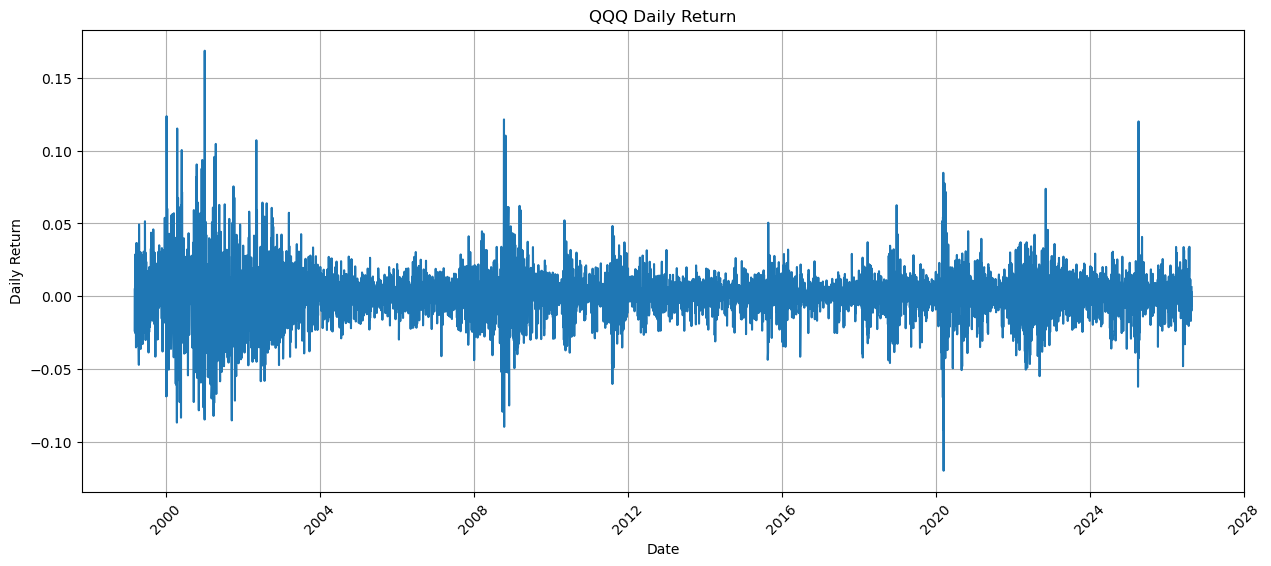

In [25]:
import matplotlib.dates as mdates

for name, df in assets.items():
    plt.figure(figsize=(15, 6))

    plt.plot(df['Date'], df['Daily_Return'])

    plt.title(f'{name} Daily Return')
    plt.xlabel('Date')
    plt.ylabel('Daily Return')

    plt.grid(True)

  
    plt.xticks(rotation=45)

    plt.savefig(
        FIGURES / f'{name}_daily_return.png',
        dpi=300,
        bbox_inches='tight'
    )



    plt.show()
    

    

In [ ]:
# Daily Return Distribution

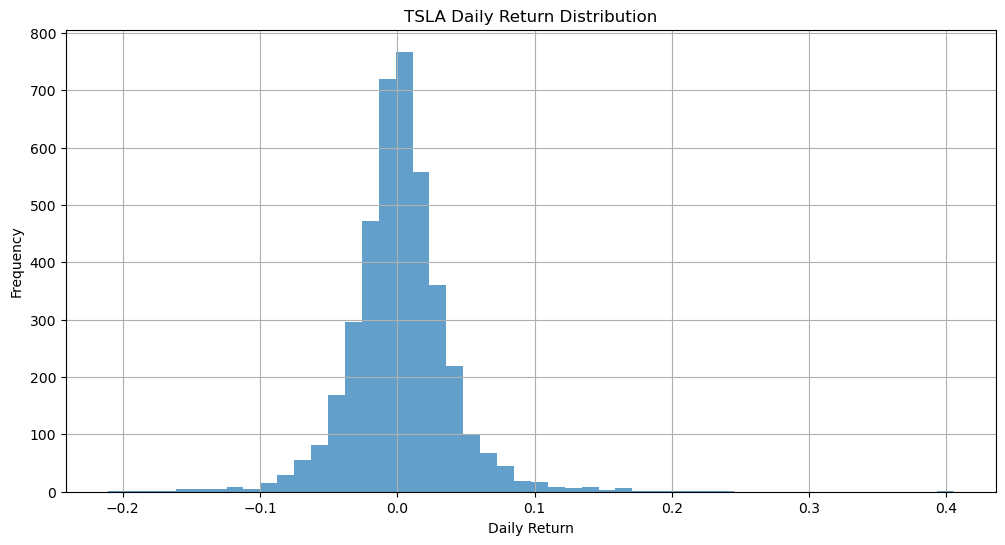

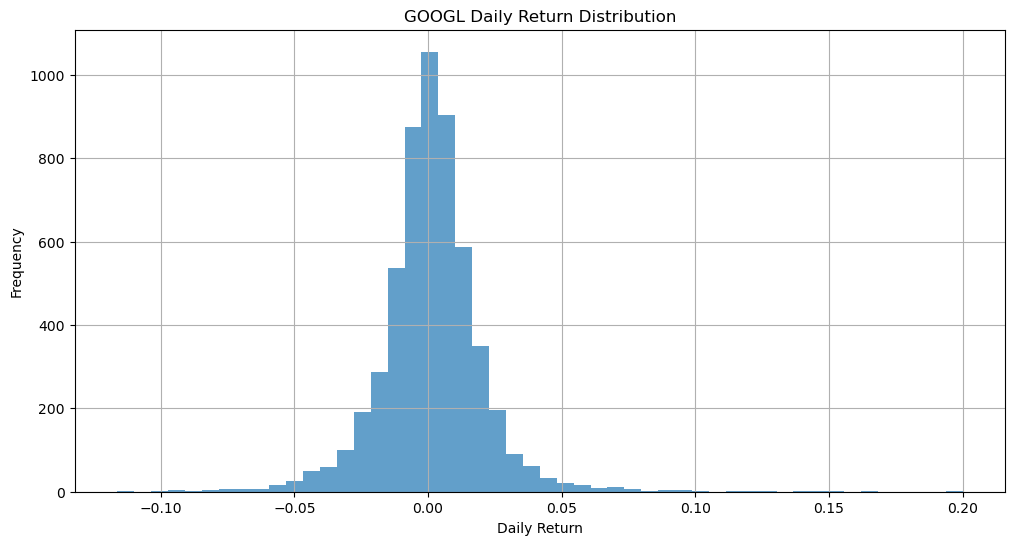

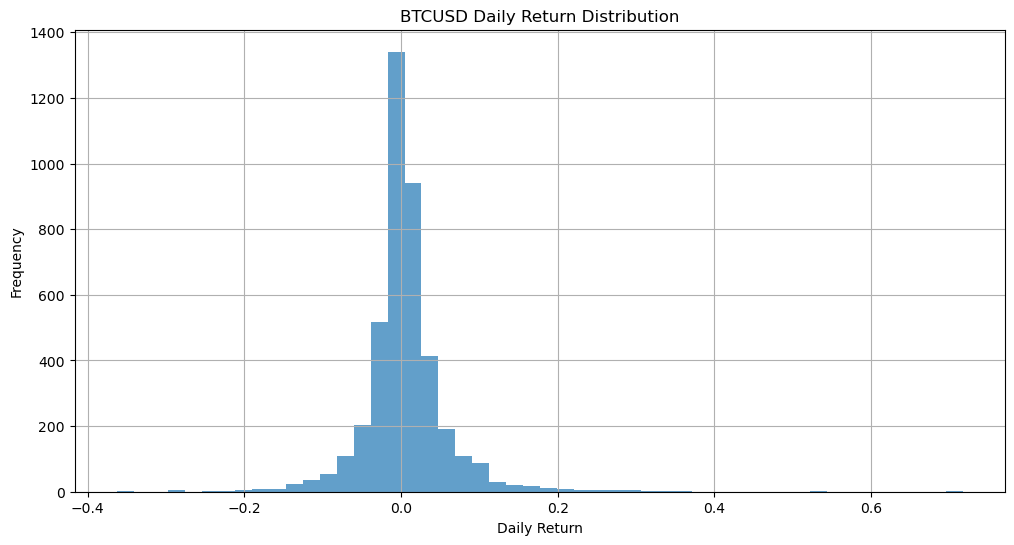

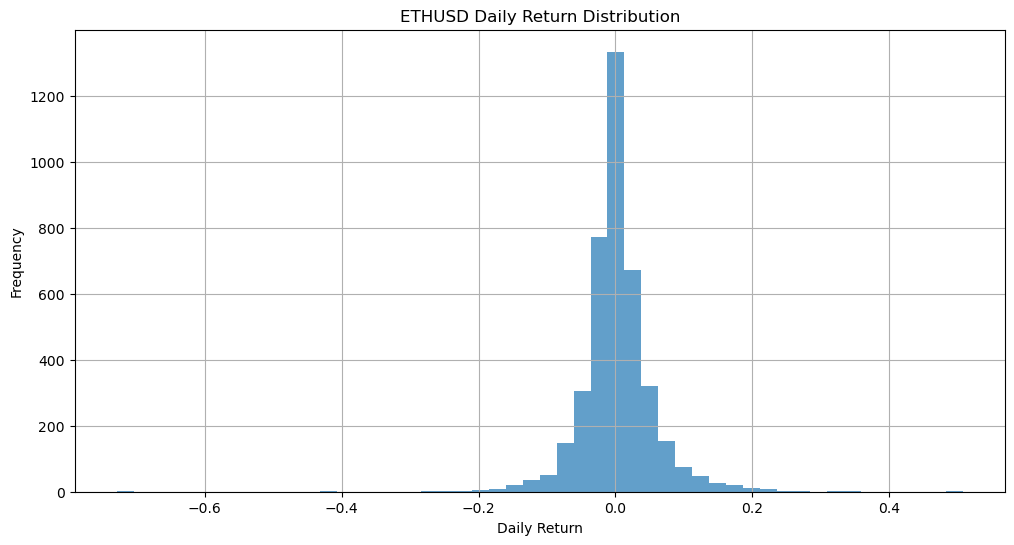

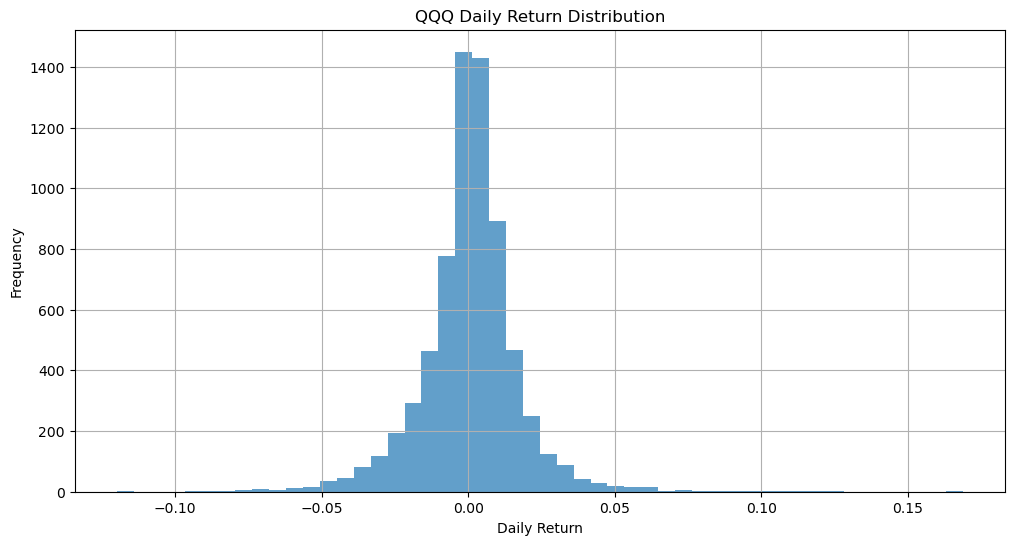

In [28]:
for name, df in assets.items():
    plt.figure(figsize=(12, 6))

    plt.hist(
        df['Daily_Return'].dropna(),
        bins=50,
        alpha=0.7
    )

    plt.title(f'{name} Daily Return Distribution')
    plt.xlabel('Daily Return')
    plt.ylabel('Frequency')

    plt.grid(True)

    plt.savefig(
        FIGURES / f'{name}_daily_return_distribution.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [29]:
# Cumulative Return

In [31]:
for name,df in assets.items():
    df['Cumulative Return']=(1+df['Daily Return']).cumprod()-1

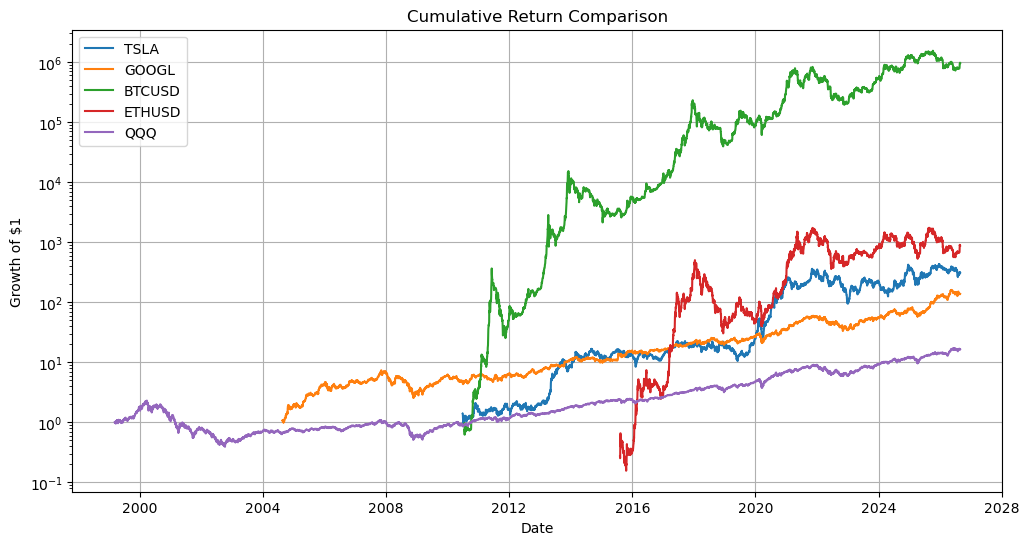

In [40]:
plt.figure(figsize=(12, 6))

for name, df in assets.items():
    plt.plot(
        df["Date"],
        1 + df["Cumulative Return"],
        label=name
    )

plt.title("Cumulative Return Comparison")

plt.xlabel("Date")

plt.ylabel("Growth of $1")

plt.yscale("log")

plt.legend()

plt.grid(True)

plt.savefig(
    FIGURES / "cumulative_return_comparison_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
# Rolling Volatility

In [42]:
for name,df in assets.items():
    df['Rolling Volability 20D']=df['Daily Return'].rolling(window=20).std()

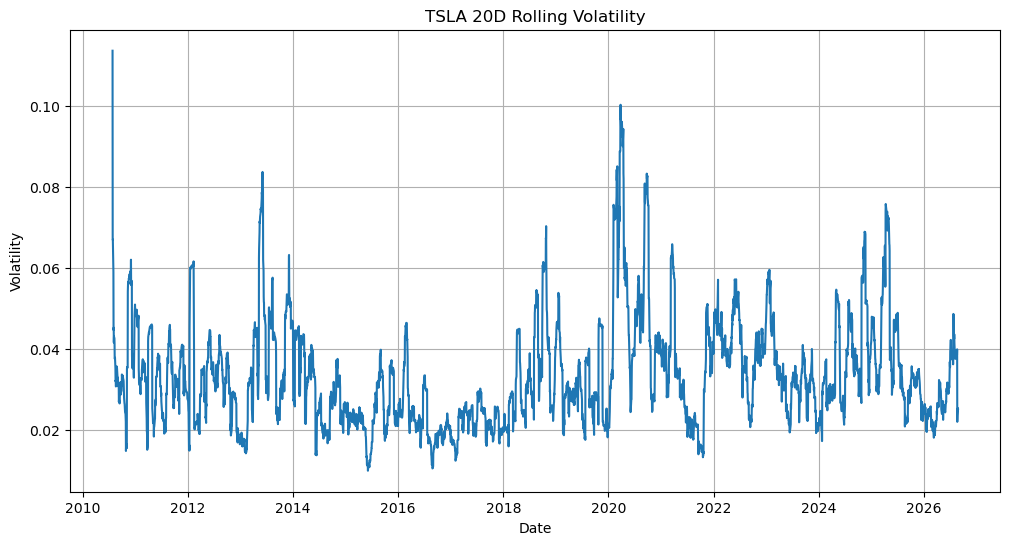

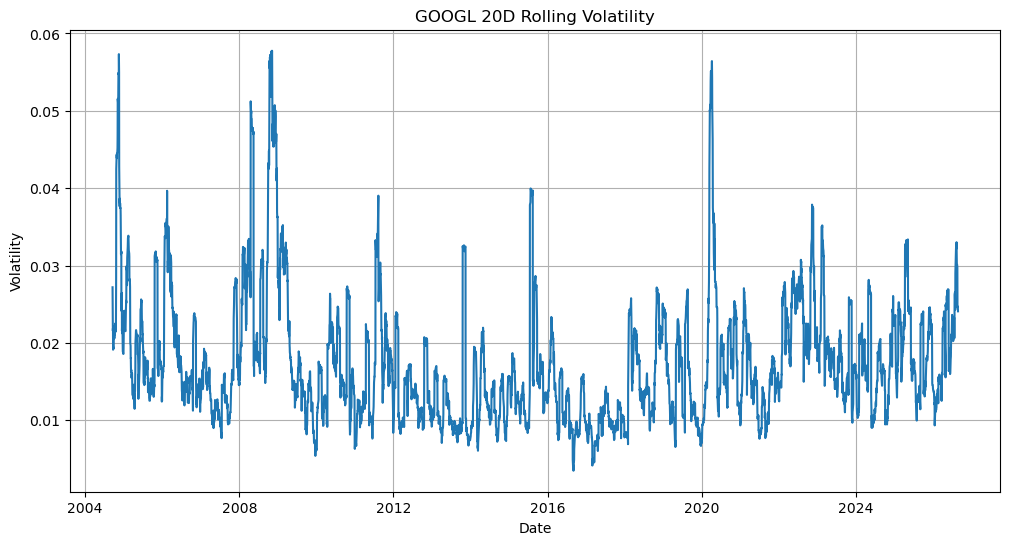

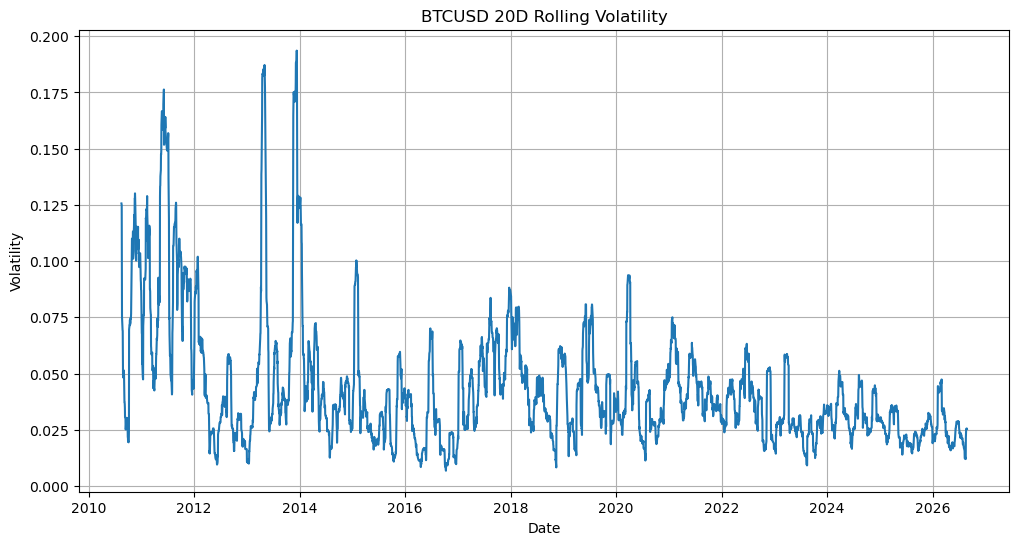

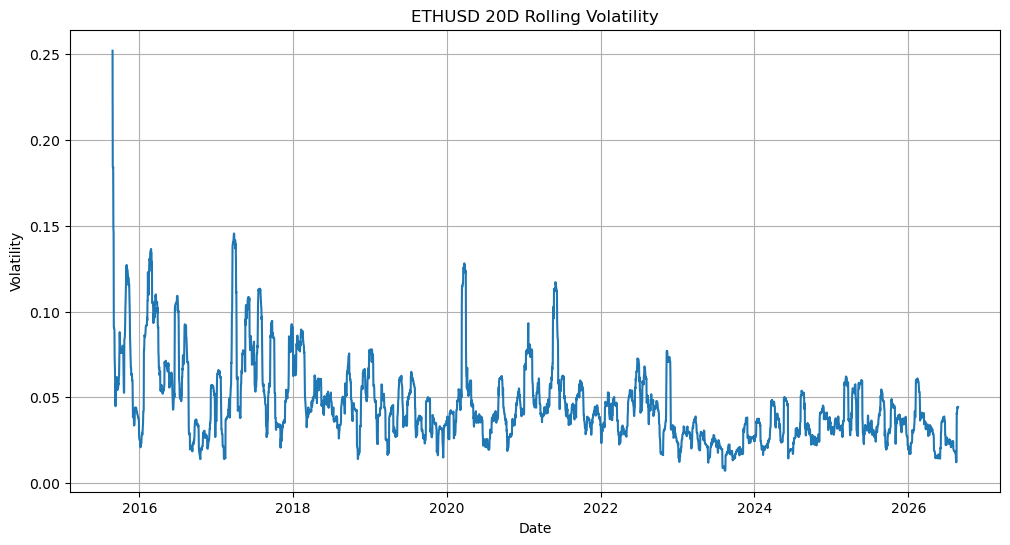

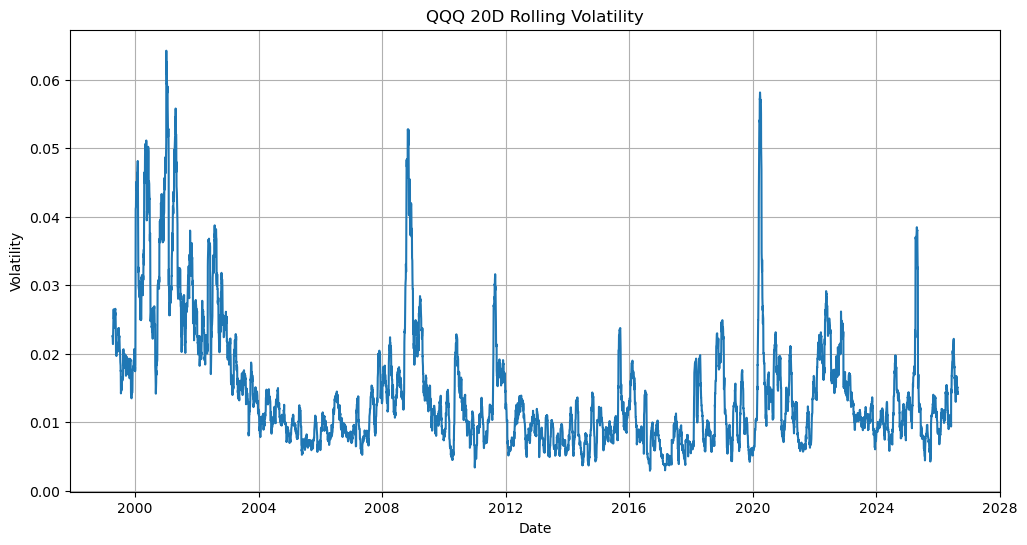

In [49]:
for name,df in assets.items():
    plt.figure(figsize=(12,6))

    plt.plot(df['Date'],df['Rolling Volability 20D'])

    plt.title(f'{name} 20D Rolling Volatility')

    plt.xlabel('Date')

    plt.ylabel('Volatility')

    plt.grid(True)

    
    plt.savefig(
        FIGURES / f"{name}_20D_rolling_volatility.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

In [56]:
returns = pd.DataFrame()

for name, df in assets.items():
    temp = df[["Date", "Daily_Return"]].copy()
    temp = temp.rename(columns={"Daily_Return": name})

    if returns.empty:
        returns = temp
    else:
        returns = returns.merge(temp, on="Date", how="outer")

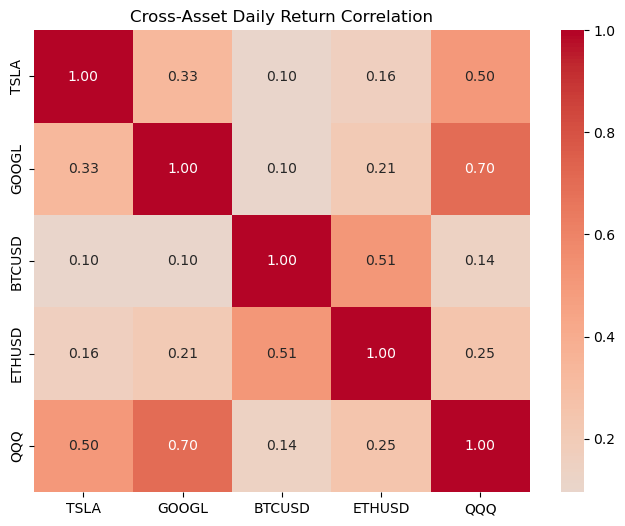

In [59]:
plt.figure(figsize=(8, 6))

correlation_matrix = returns.drop(columns="Date").corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Cross-Asset Daily Return Correlation")

plt.savefig(
    FIGURES / "cross_asset_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# Feature Engineering

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
RESULTS = PROJECT_ROOT / "results"

In [7]:
tsla = pd.read_csv(DATA_PROCESSED / "TSLA_processed.csv")
googl = pd.read_csv(DATA_PROCESSED / "GOOGL_processed.csv")
btc = pd.read_csv(DATA_PROCESSED / "BTCUSD_processed.csv")
eth = pd.read_csv(DATA_PROCESSED / "ETHUSD_processed.csv")
qqq = pd.read_csv(DATA_PROCESSED / "QQQ_processed.csv")

In [8]:
assets = {
    "TSLA": tsla,
    "GOOGL": googl,
    "BTCUSD": btc,
    "ETHUSD": eth,
    "QQQ": qqq
}

for name, df in assets.items():
    df["Date"] = pd.to_datetime(df["Date"])

In [11]:
for name, df in assets.items():
    df["Daily_Return"] = df["Close"].pct_change()

In [12]:
for name, df in assets.items():
    df["Rolling_Volatility_20D"] = (
        df["Daily_Return"]
        .rolling(window=20)
        .std()
    )

In [13]:
### Momentum Features

Momentum measures how much an asset's price has changed relative to a previous point in time.

In this project, three momentum horizons are used:

- **5-Day Momentum** — captures very short-term price direction
- **20-Day Momentum** — captures approximately one month of recent trend information
- **60-Day Momentum** — captures a broader medium-term trend

A positive momentum value indicates that the asset has appreciated over the selected lookback period, while a negative value indicates a decline.

Momentum is included because financial assets may exhibit **trend persistence**, where recent price movements can contain information about subsequent returns. 
Using multiple horizons allows the model to distinguish between short-term and medium-term market trends.
However, momentum is not assumed to be predictive by itself. Its usefulness will later be evaluated through the forecasting models and compared across different assets 
and forecast horizons.
Momentum features help the model distinguish between short-lived price movements and more persistent trends by measuring returns over multiple lookback periods.

,Date,Open,High,Low,Close,Volume,Daily_Return,Rolling_Volatility_20D
0,1999-03-10,43.3466,43.3734,42.6342,43.2932,12341014,NaN,NaN
1,1999-03-11,43.6069,43.8567,42.6525,43.4977,22856485,0.004724,NaN
2,1999-03-12,43.3457,43.3724,42.1014,42.4471,20624340,-0.024153,NaN
3,1999-03-15,42.7595,43.7109,42.3081,43.6631,15025284,0.028647,NaN
4,1999-03-16,43.8498,44.2200,43.3724,44.0379,11571731,0.008584,NaN


In [16]:
for name,df in assets.items():
    df['Momentum_5D']=df['Close'].pct_change(5)
    df['Momentum_20D']=df['Close'].pct_change(20)
    df['Momentum_60D']=df['Close'].pct_change(60)

In [18]:
### Moving Average and Price-to-Moving-Average Features

Moving averages are used to represent the recent average price level of an asset.

This project uses:

- **MA20** — 20-period moving average
- **MA60** — 60-period moving average

The price-to-moving-average features measure how far the current closing price is above or below its recent average:


A positive value means the current price is above its recent average, while a negative value means the price is below the average.

These features may help capture both **momentum** and **mean-reversion** behaviour. A price that remains above its moving average may indicate trend persistence, while a large deviation from the moving average may also signal a potential tendency to revert toward its longer-term mean.

Using both 20-period and 60-period averages allows the model to compare shorter-term and medium-term trend conditions.

,Date,Open,High,Low,Close,Volume,Daily_Return,Rolling_Volatility_20D,Momentum_5D,Momentum_20D,Momentum_60D
0,2010-06-28,1.13333,1.13333,1.133330,1.13333,0,NaN,NaN,NaN,NaN,NaN
1,2010-06-29,1.26667,1.66667,1.169330,1.59267,281749140,0.405301,NaN,NaN,NaN,NaN
2,2010-06-30,1.71933,2.02800,1.553330,1.58867,257915910,-0.002512,NaN,NaN,NaN,NaN
3,2010-07-01,1.66667,1.72800,1.351330,1.46400,123447945,-0.078474,NaN,NaN,NaN,NaN
4,2010-07-02,1.53333,1.54000,1.247330,1.28000,77127105,-0.125683,NaN,NaN,NaN,NaN
5,2010-07-06,1.33333,1.33333,1.055330,1.07400,103189440,-0.160937,NaN,-0.052350,NaN,NaN
6,2010-07-07,1.09333,1.10867,0.998667,1.05333,103873710,-0.019246,NaN,-0.338639,NaN,NaN
7,2010-07-08,1.07600,1.16800,1.038000,1.16400,115793085,0.105067,NaN,-0.267312,NaN,NaN
8,2010-07-09,1.17200,1.19333,1.103330,1.16000,60879090,-0.003436,NaN,-0.207650,NaN,NaN
9,2010-07-12,1.19667,1.20467,1.133330,1.13667,33053550,-0.020112,NaN,-0.111977,NaN,NaN


In [21]:
for name,df in assets.items():
    df['MA20']=df['Close'].rolling(window=20).mean()
    df['MA60']=df['Close'].rolling(window=60).mean()
    
    df['Price_to_MA20']=df['Close']/df['MA20']
    df['Price_to_MA60']=df['Close']/df['MA60']

In [22]:
tsla[
    [
        "Date",
        "Close",
        "MA20",
        "MA60",
        "Price_to_MA20",
        "Price_to_MA60"
    ]
].head(65)

,Date,Close,MA20,MA60,Price_to_MA20,Price_to_MA60
0,2010-06-28,1.13333,NaN,NaN,NaN,NaN
1,2010-06-29,1.59267,NaN,NaN,NaN,NaN
2,2010-06-30,1.58867,NaN,NaN,NaN,NaN
3,2010-07-01,1.46400,NaN,NaN,NaN,NaN
4,2010-07-02,1.28000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
60,2010-09-22,1.32467,1.367533,1.332489,0.968656,0.994132
61,2010-09-23,1.30400,1.366400,1.327678,0.954333,0.982166
62,2010-09-24,1.34000,1.367566,1.323533,0.979843,1.012442
63,2010-09-27,1.36867,1.370334,1.321944,0.998786,1.035346


### Volatility Regime Feature

The 20-day rolling volatility is converted into three volatility regimes:

- **Low Volatility**
- **Medium Volatility**
- **High Volatility**

Because different assets have very different normal volatility levels, fixed volatility thresholds are not applied across all assets.

Instead, each asset's own historical rolling-volatility distribution is divided using approximately the 33rd and 67th percentiles.

This allows the regime variable to represent whether the current volatility level is relatively low, normal, or high compared with the asset's own historical behaviour.

Volatility regimes are included because the EDA showed that market risk is time-varying and tends to cluster. Forecasting relationships may therefore differ between calm and stressed market environments.

### Why Use Volatility Regimes?

Rolling volatility measures the current level of market risk, while a volatility regime classifies that risk into different market environments such as low, medium, and high volatility.

The EDA showed that volatility is time-varying and tends to cluster, meaning that calm and stressed market conditions often persist for a period of time.

A volatility regime feature allows the model to distinguish between these different environments. This is useful because the predictive value of other features, such as momentum or moving-average signals, may change depending on whether the market is calm or highly volatile.

Therefore, volatility regimes are included to help the forecasting model capture regime-dependent behaviour rather than assuming that market conditions remain constant through time.

In [23]:
for name,df in assets.items():
    q1=df['Rolling_Volatility_20D'].quantile(0.33)
    q2=df['Rolling_Volatility_20D'].quantile(0.67)

    df['Volatility_Regime']=pd.cut(df['Rolling_Volatility_20D'],bins=[-np.inf,q1,q2,np.inf],labels=['Low','Medium','High'])
    

In [26]:
tsla.tail(10)

,Date,Open,High,Low,Close,Volume,Daily_Return,Rolling_Volatility_20D,Momentum_5D,Momentum_20D,Momentum_60D,MA20,MA60,Price_to_MA20,Price_to_MA60,Volatility_Regime
4054,2026-08-12,335.00,335.50,323.6400,327.51,28698879,-0.015925,0.038298,0.018535,-0.169726,-0.224351,333.6230,382.707000,0.981677,0.855772,High
4055,2026-08-13,327.20,341.64,325.2400,339.96,34708303,0.038014,0.039685,0.063938,-0.130670,-0.170809,331.0680,381.539833,1.026859,0.891021,High
4056,2026-08-14,342.33,351.26,335.3306,342.27,45437144,0.006795,0.039496,0.041664,-0.101276,-0.153028,329.1395,380.509167,1.039893,0.899505,High
4057,2026-08-17,340.69,345.45,337.4800,339.30,26037093,-0.008677,0.039073,0.025447,-0.081906,-0.186838,327.6260,379.209833,1.035632,0.894755,High
4058,2026-08-18,333.22,340.53,331.1200,336.87,27994466,-0.007162,0.038483,0.012199,-0.110997,-0.193802,325.5230,377.860167,1.034858,0.891520,High
4059,2026-08-19,338.89,351.62,335.7000,351.12,36735428,0.042301,0.039849,0.072089,-0.061202,-0.175794,324.3785,376.612000,1.082439,0.932312,High
4060,2026-08-20,346.20,347.50,338.9600,345.13,30766360,-0.017060,0.021942,0.015208,0.079577,-0.204018,325.6505,375.137667,1.059817,0.920009,Low
4061,2026-08-21,349.88,366.50,346.9000,362.86,59223958,0.051372,0.023514,0.060157,0.159186,-0.175992,328.1420,373.846000,1.105802,0.970614,Low
4062,2026-08-24,361.41,363.24,348.2600,348.95,39190484,-0.038334,0.025334,0.028441,0.128485,-0.210699,330.1285,372.293500,1.057013,0.937298,Low
4063,2026-08-25,349.58,357.00,349.2003,350.25,29816685,0.003725,0.025183,0.039719,0.139247,-0.196287,332.2690,370.867833,1.054116,0.944407,Low


In [ ]:
### Market-Relative Features

QQQ is used as an equity-market benchmark for TSLA and GOOGL.

The daily excess return relative to QQQ is calculated as:

\[
Excess\ Return_{t} = Asset\ Return_{t} - QQQ\ Return_{t}
\]

A positive value indicates that the stock outperformed QQQ on that day, while a negative value indicates underperformance.

This feature is included because stock returns are influenced by both market-wide movements and asset-specific factors. 
Removing the benchmark component helps the model distinguish between broad market effects 
and stock-specific relative performance.

In [35]:
qqq_returns=qqq[['Date','Daily_Return']].copy()
qqq_returns=qqq_returns.rename(columns={'Daily_Return':'QQQ_Return'})

In [36]:
for name in ["TSLA", "GOOGL"]:
    df = assets[name]

    df = df.merge(
        qqq_returns,
        on="Date",
        how="left"
    )

    df["Excess_Return_vs_QQQ"] = (
        df["Daily_Return"] - df["QQQ_Return"]
    )

    assets[name] = df

KeyError: 'QQQ_Return'

In [ ]:
### Why Construct Multi-Horizon Targets?

Random Forest is a supervised learning model, so it needs both input features and a clearly defined prediction target.

For each historical date, the model uses the market information available on that day, such as momentum, moving-average deviation, volatility, volatility regime, and benchmark-relative performance, as the input features.

The future price at different forecast horizons is then used to calculate the corresponding future return, such as 30-day, 3-month, 6-month, or 1-year return. These future returns become the target variables that the Random Forest learns to predict.

In other words, the model learns the relationship between the market conditions observed today and the asset's subsequent performance over different time horizons.

By constructing separate targets for each horizon, we can train and evaluate Random Forest models at different forecasting horizons and determine whether the current features are more useful for short-term, medium-term, or long-term prediction.

The predicted future return can later be converted back into a forecast price using the current asset price.

In [ ]:
### Why Random Forest Requires Explicit Forecast Targets

Although Random Forest can and should use a chronological train-test split, the split itself does not define what the model is predicting.

Random Forest is a supervised learning model and follows the structure:

\[
X \rightarrow y
\]

where \(X\) represents the input features and \(y\) represents the prediction target.

A chronological train-test split only determines which historical observations are used for training and which later observations are used for testing. It does not automatically tell the model whether it should predict the asset price 30 days, 3 months, or 1 year into the future.

Therefore, future targets must first be constructed explicitly. For example:

- Current features → 30-day future return
- Current features → 3-month future return
- Current features → 1-year future return

Each forecast horizon creates a different supervised learning problem.

This differs from ARIMA, which is designed specifically for time-series forecasting. ARIMA models the sequential dependence of a time series and can directly forecast a specified number of future steps after being trained on historical observations.

Therefore:

- **Target construction** defines *what Random Forest should predict*.
- **Chronological train-test split** defines *which observations are used for training and evaluation*.

Both steps are required for Random Forest forecasting.

In [46]:
def create_multi_horizon_targets(df):
    df = df.copy()
    df = df.sort_values("Date").reset_index(drop=True)

    horizons = {
        "30D": pd.Timedelta(days=30),
        "3M": pd.DateOffset(months=3),
        "6M": pd.DateOffset(months=6),
        "1Y": pd.DateOffset(years=1),
        "3Y": pd.DateOffset(years=3),
        "5Y": pd.DateOffset(years=5),
        "10Y": pd.DateOffset(years=10)
    }

    future_prices = df[["Date", "Close"]].copy()
    future_prices = future_prices.rename(
        columns={
            "Date": "Future_Date",
            "Close": "Future_Close"
        }
    )

    for horizon_name, offset in horizons.items():

        target_date_col = f"Target_Date_{horizon_name}"
        future_date_col = f"Future_Date_{horizon_name}"
        future_close_col = f"Future_Close_{horizon_name}"
        future_return_col = f"Future_Return_{horizon_name}"

        df[target_date_col] = df["Date"] + offset

        future_temp = future_prices.rename(
            columns={
                "Future_Date": future_date_col,
                "Future_Close": future_close_col
            }
        )

        df = pd.merge_asof(
            df.sort_values(target_date_col),
            future_temp.sort_values(future_date_col),
            left_on=target_date_col,
            right_on=future_date_col,
            direction="forward"
        )

        df[future_return_col] = (
            df[future_close_col] / df["Close"] - 1
        )

        df = df.sort_values("Date").reset_index(drop=True)

    return df

In [47]:
tsla_modeling=create_multi_horizon_targets(assets['TSLA'])

In [50]:
tsla_modeling[
    [
        "Date",
        "Close",
        "Future_Return_30D",
        "Future_Return_3M",
        "Future_Return_6M",
        "Future_Return_1Y",
        "Future_Return_3Y",
        "Future_Return_5Y",
        "Future_Return_10Y"
    ]
].head(20)

,Date,Close,Future_Return_30D,Future_Return_3M,Future_Return_6M,Future_Return_1Y,Future_Return_3Y,Future_Return_5Y,Future_Return_10Y
0,2010-06-28,1.13333,0.218824,0.258830,0.553537,0.653534,5.315310,14.412987,58.373704
1,2010-06-29,1.59267,-0.148179,-0.079954,0.160736,0.184175,3.904971,9.967746,41.249807
2,2010-06-30,1.58867,-0.163243,-0.143516,0.112043,0.222406,3.917321,10.257215,44.312557
3,2010-07-01,1.46400,-0.047357,-0.061933,0.212206,0.321496,4.336066,11.256352,49.985861
4,2010-07-02,1.28000,0.089586,0.093227,0.386461,0.517711,5.136461,13.584375,61.950547
5,2010-07-06,1.07400,0.269395,0.270019,0.730605,0.797644,6.548724,16.363128,84.139665
6,2010-07-07,1.05333,0.239877,0.293042,0.787351,0.881652,6.696857,15.954516,86.965500
7,2010-07-08,1.16400,0.122569,0.170103,0.629442,0.650060,5.965060,13.602491,77.230241
8,2010-07-09,1.16000,0.126440,0.163216,0.635060,0.629310,6.094828,13.823017,79.132155
9,2010-07-12,1.13667,0.049847,0.187090,0.581224,0.652195,6.618746,14.375879,86.803232


In [51]:
# 1. 检查30D日期匹配
tsla_modeling[
    ["Date", "Target_Date_30D", "Future_Date_30D",
     "Close", "Future_Close_30D", "Future_Return_30D"]
].head(10)

,Date,Target_Date_30D,Future_Date_30D,Close,Future_Close_30D,Future_Return_30D
0,2010-06-28,2010-07-28,2010-07-28,1.13333,1.38133,0.218824
1,2010-06-29,2010-07-29,2010-07-29,1.59267,1.35667,-0.148179
2,2010-06-30,2010-07-30,2010-07-30,1.58867,1.32933,-0.163243
3,2010-07-01,2010-07-31,2010-08-02,1.46400,1.39467,-0.047357
4,2010-07-02,2010-08-01,2010-08-02,1.28000,1.39467,0.089586
5,2010-07-06,2010-08-05,2010-08-05,1.07400,1.36333,0.269395
6,2010-07-07,2010-08-06,2010-08-06,1.05333,1.30600,0.239877
7,2010-07-08,2010-08-07,2010-08-09,1.16400,1.30667,0.122569
8,2010-07-09,2010-08-08,2010-08-09,1.16000,1.30667,0.126440
9,2010-07-12,2010-08-11,2010-08-11,1.13667,1.19333,0.049847


In [52]:
# 2. 检查10Y日期匹配
tsla_modeling[
    ["Date", "Target_Date_10Y", "Future_Date_10Y",
     "Close", "Future_Close_10Y", "Future_Return_10Y"]
].head(10)

,Date,Target_Date_10Y,Future_Date_10Y,Close,Future_Close_10Y,Future_Return_10Y
0,2010-06-28,2020-06-28,2020-06-29,1.13333,67.2900,58.373704
1,2010-06-29,2020-06-29,2020-06-29,1.59267,67.2900,41.249807
2,2010-06-30,2020-06-30,2020-06-30,1.58867,71.9867,44.312557
3,2010-07-01,2020-07-01,2020-07-01,1.46400,74.6433,49.985861
4,2010-07-02,2020-07-02,2020-07-02,1.28000,80.5767,61.950547
5,2010-07-06,2020-07-06,2020-07-06,1.07400,91.4400,84.139665
6,2010-07-07,2020-07-07,2020-07-07,1.05333,92.6567,86.965500
7,2010-07-08,2020-07-08,2020-07-08,1.16400,91.0600,77.230241
8,2010-07-09,2020-07-09,2020-07-09,1.16000,92.9533,79.132155
9,2010-07-12,2020-07-12,2020-07-13,1.13667,99.8033,86.803232


In [53]:
# 3. 检查数据末尾的NaN
tsla_modeling[
    ["Date", "Future_Return_30D", "Future_Return_1Y",
     "Future_Return_3Y", "Future_Return_5Y", "Future_Return_10Y"]
].tail(20)

,Date,Future_Return_30D,Future_Return_1Y,Future_Return_3Y,Future_Return_5Y,Future_Return_10Y
4044,2026-07-29,NaN,NaN,NaN,NaN,NaN
4045,2026-07-30,NaN,NaN,NaN,NaN,NaN
4046,2026-07-31,NaN,NaN,NaN,NaN,NaN
4047,2026-08-03,NaN,NaN,NaN,NaN,NaN
4048,2026-08-04,NaN,NaN,NaN,NaN,NaN
4049,2026-08-05,NaN,NaN,NaN,NaN,NaN
4050,2026-08-06,NaN,NaN,NaN,NaN,NaN
4051,2026-08-07,NaN,NaN,NaN,NaN,NaN
4052,2026-08-10,NaN,NaN,NaN,NaN,NaN
4053,2026-08-11,NaN,NaN,NaN,NaN,NaN


In [54]:
googl_modeling = create_multi_horizon_targets(
    assets["GOOGL"]
)

btc_modeling = create_multi_horizon_targets(
    assets["BTCUSD"]
)

eth_modeling = create_multi_horizon_targets(
    assets["ETHUSD"]
)

In [55]:
modeling_assets = {
    "TSLA": tsla_modeling,
    "GOOGL": googl_modeling,
    "BTCUSD": btc_modeling,
    "ETHUSD": eth_modeling
}

In [57]:
for name,df in modeling_assets.items():
    df.to_csv(DATA_MODELING/ f'{name}_modeling.csv',index=False)